In [1]:
import os
import sys
import torch
from torchvision import transforms
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm
import time
from torch.utils.data import DataLoader
import Levenshtein
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from PIL import Image
from torchinfo import summary

sys.path.append(os.path.abspath(os.path.join("../..")))
from src.datasets.huggingfacefilelistdataset import HuggingFaceFileListDataset
from src.models.convoluationaltransformer.convtrans_v1 import Captcha_Convolutional_Transformer_V1

# Load Test-Data & Model

In [2]:
captcha_transformation = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((40, 150)),
        transforms.ToTensor(),
        # transforms.Normalize(mean=[0.5], std=[0.5])
    ]
)
hf_dataset = HuggingFaceFileListDataset(
    file_list="../convtrans/test_file_list_convtrans_v6.txt",
    transform=captcha_transformation
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Captcha_Convolutional_Transformer_V1(num_chars=len(hf_dataset.vocab) + 1)
state_dict = torch.load(Captcha_Convolutional_Transformer_V1.SAVE_DIR / "v6.pth", map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval() 

print(f"Model successfully loaded from {Captcha_Convolutional_Transformer_V1.SAVE_DIR / "v6.pth"}")

/nfs/home/tpz8688/Captcha-Recognition/src/models/convoluationaltransformer/convtrans_v1.py:93: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Model successfully loaded from /nfs/home/tpz8688/Captcha-Recognition/weights/conv_transformer/v6.pth


# Helper Functions

In [4]:
def decode_predictions(logits, dataset):
    tokens = torch.argmax(logits, dim=-1)

    char_list = []
    for i in range(len(tokens)):
        token = tokens[i].item()
        if token != 0:
            if i > 0 and tokens[i] == tokens[i - 1]:
                continue
            char_list.append(dataset.idx_to_char[token])

    return "".join(char_list)

In [5]:
def captcha_collate_fn(batch):
    # Back to the original 3 values
    images, labels, lengths = zip(*batch)
    
    images = torch.stack(images, 0)
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=0)
    label_lengths = torch.tensor(lengths, dtype=torch.long)
    
    return images, labels_padded, label_lengths

In [6]:
def compute_cer(df, pred_column):
    # fillna("") ensures all NaNs become empty strings
    actual = df["actual"].fillna("").astype(str).values
    pred = df[pred_column].fillna("").astype(str).values

    total_distance = 0
    total_chars = 0

    for gt, pr in zip(actual, pred):
        total_distance += Levenshtein.distance(gt, pr)
        total_chars += len(gt)

    return total_distance / max(1, total_chars)

In [7]:
def plot_char_confusion_matrix(results_df, dataset, hide_diagonal=False):
    char_actual = []
    char_pred = []
    
    vocab = sorted(list(dataset.vocab))
    labels = vocab + ['Ø'] 
    
    for _, row in results_df.iterrows():
        # FIX: Force conversion to string and replace NaN with empty string
        actual = str(row['actual']) if pd.notna(row['actual']) else ""
        pred = str(row['prediction']) if pd.notna(row['prediction']) else ""
        
        # Now max(len(actual), len(pred)) will work even if one is empty
        max_len = max(len(actual), len(pred))
        actual_padded = actual.ljust(max_len, 'Ø') 
        pred_padded = pred.ljust(max_len, 'Ø')
        
        for a, p in zip(actual_padded, pred_padded):
            char_actual.append(a)
            char_pred.append(p)

    # Generate the raw confusion matrix
    cm = confusion_matrix(char_actual, char_pred, labels=labels)
    
    # If requested, zero out the diagonal to highlight errors
    if hide_diagonal:
        np.fill_diagonal(cm, 0)
        title = 'Character-Level Confusion Matrix (Errors Only)'
        cmap = 'OrRd' # Switching to red-scale makes errors pop more
    else:
        title = 'Character-Level Confusion Matrix'
        cmap = 'Blues'
    
    # Plotting
    plt.figure(figsize=(22, 18))
    sns.heatmap(cm, annot=False, fmt='d', cmap=cmap, 
                xticklabels=labels, yticklabels=labels)
    
    plt.xlabel('Predicted Character')
    plt.ylabel('Actual Character')
    plt.title(title)
    plt.show()

In [8]:
def visualize_test_predictions(df, dataset, num_images):
    # Select random samples from the dataframe
    sample_indices = random.sample(range(len(df)), num_images)
    samples = df.iloc[sample_indices]

    fig, axes = plt.subplots(num_images, 2, figsize=(12, num_images * 2))
    
    # If num_images is 1, axes is not a 2D array, so we wrap it
    if num_images == 1:
        axes = axes.reshape(1, 2)

    for i, (_, row) in enumerate(samples.iterrows()):
        idx = int(row['index'])
        path = row['path']
        actual = row['actual']
        prediction = row['prediction']
        
        # 1. Load Original Image (Raw froam disk)
        raw_img = Image.open(path).convert("RGB")
        
        # 2. Get Transformed Image (From dataset __getitem__)
        # dataset[idx] returns (transformed_tensor, label, length)
        transformed_tensor, _, _ = dataset[idx]
        
        # Convert tensor [1, 40, 150] back to image for plotting
        transformed_img = transformed_tensor.squeeze().cpu().numpy()

        # Plot Original
        axes[i, 0].imshow(raw_img)
        axes[i, 0].set_title(f"Original (Index: {idx})")
        axes[i, 0].axis('off')

        # Plot Transformed
        # Use cmap='gray' since your transform is Grayscale
        axes[i, 1].imshow(transformed_img, cmap='gray')
        
        # Color coding: Green if correct, Red if wrong
        color = 'green' if actual == prediction else 'red'
        title_text = f"Actual: {actual} | Pred: {prediction}"
        
        axes[i, 1].set_title(title_text, color=color, fontweight='bold')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [9]:
def run_test_inference(model, dataset, device, batch_size=256, num_workers=16):
    model.eval()
    
    # shuffle MUST be False for the index tracking to work
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=captcha_collate_fn,
        prefetch_factor=2
    )

    idx_to_char = dataset.idx_to_char
    all_results = []
    
    # We track the current global index manually
    current_global_idx = 0

    print(f"Starting inference on {len(dataset)} images...")
    
    with torch.no_grad():
        for batch_idx, (images, labels, _) in enumerate(tqdm(loader, desc="Testing")):
            images = images.to(device, non_blocking=True)
            logits = model(images) 

            # Vectorized Decoding
            preds = logits.argmax(dim=2)
            shifted = torch.roll(preds, shifts=1, dims=1)
            shifted[:, 0] = -1
            collapsed_preds = preds * (preds != shifted)

            for i in range(preds.size(0)):
                token_ids = collapsed_preds[i][collapsed_preds[i] != 0]
                pred_str = "".join(idx_to_char[t.item()] for t in token_ids)

                actual_ids = labels[i][labels[i] != 0]
                actual_str = "".join(idx_to_char[t.item()] for t in actual_ids)

                # Use our manual counter to get the image path
                img_path = dataset.image_paths[current_global_idx]

                if "data/generated" in str(img_path):
                    current_global_idx += 1
                    continue

                all_results.append({
                    "index": current_global_idx,
                    "path": str(img_path),
                    "actual": actual_str,
                    "prediction": pred_str,
                })
                
                # Increment the counter for every image in the batch
                current_global_idx += 1

    return all_results

# Make Predictions on Test-Data

In [10]:
test_results = run_test_inference(model, hf_dataset, device)

Starting inference on 26300 images...


Testing:   0%|          | 0/103 [00:00<?, ?it/s]

In [11]:
df_test_results = pd.DataFrame(test_results)
df_test_results.to_csv("convtrans_v6_hf_test_results.csv", index=False)

# Accuracy & Character-Error-Rate (CER)

In [13]:
df_test_results = pd.read_csv("convtrans_v6_hf_test_results.csv")
df_test_results.head()

,index,path,actual,prediction
0,1,/nfs/home/tpz8688/Captcha-Recognition/data/ham...,hctu6s,hctu6s
1,13,/nfs/home/tpz8688/Captcha-Recognition/data/ham...,CySbVj,CySbVj
2,18,/nfs/home/tpz8688/Captcha-Recognition/data/ham...,BnOFkF,BnOFkF
3,31,/nfs/home/tpz8688/Captcha-Recognition/data/ham...,3UCdsg,3UCdsg
4,32,/nfs/home/tpz8688/Captcha-Recognition/data/ham...,4JjkO4,4JjkO4


In [14]:
accuracy = (df_test_results["actual"] == df_test_results["prediction"]).sum() / len(df_test_results)
cer = compute_cer(df_test_results, "prediction")

print(f"Accuracy:             {accuracy:.2%}")
print(f"Character-Error-Rate: {cer:.2%}")

Accuracy:             95.36%
Character-Error-Rate: 1.03%


# Confusion Matrix

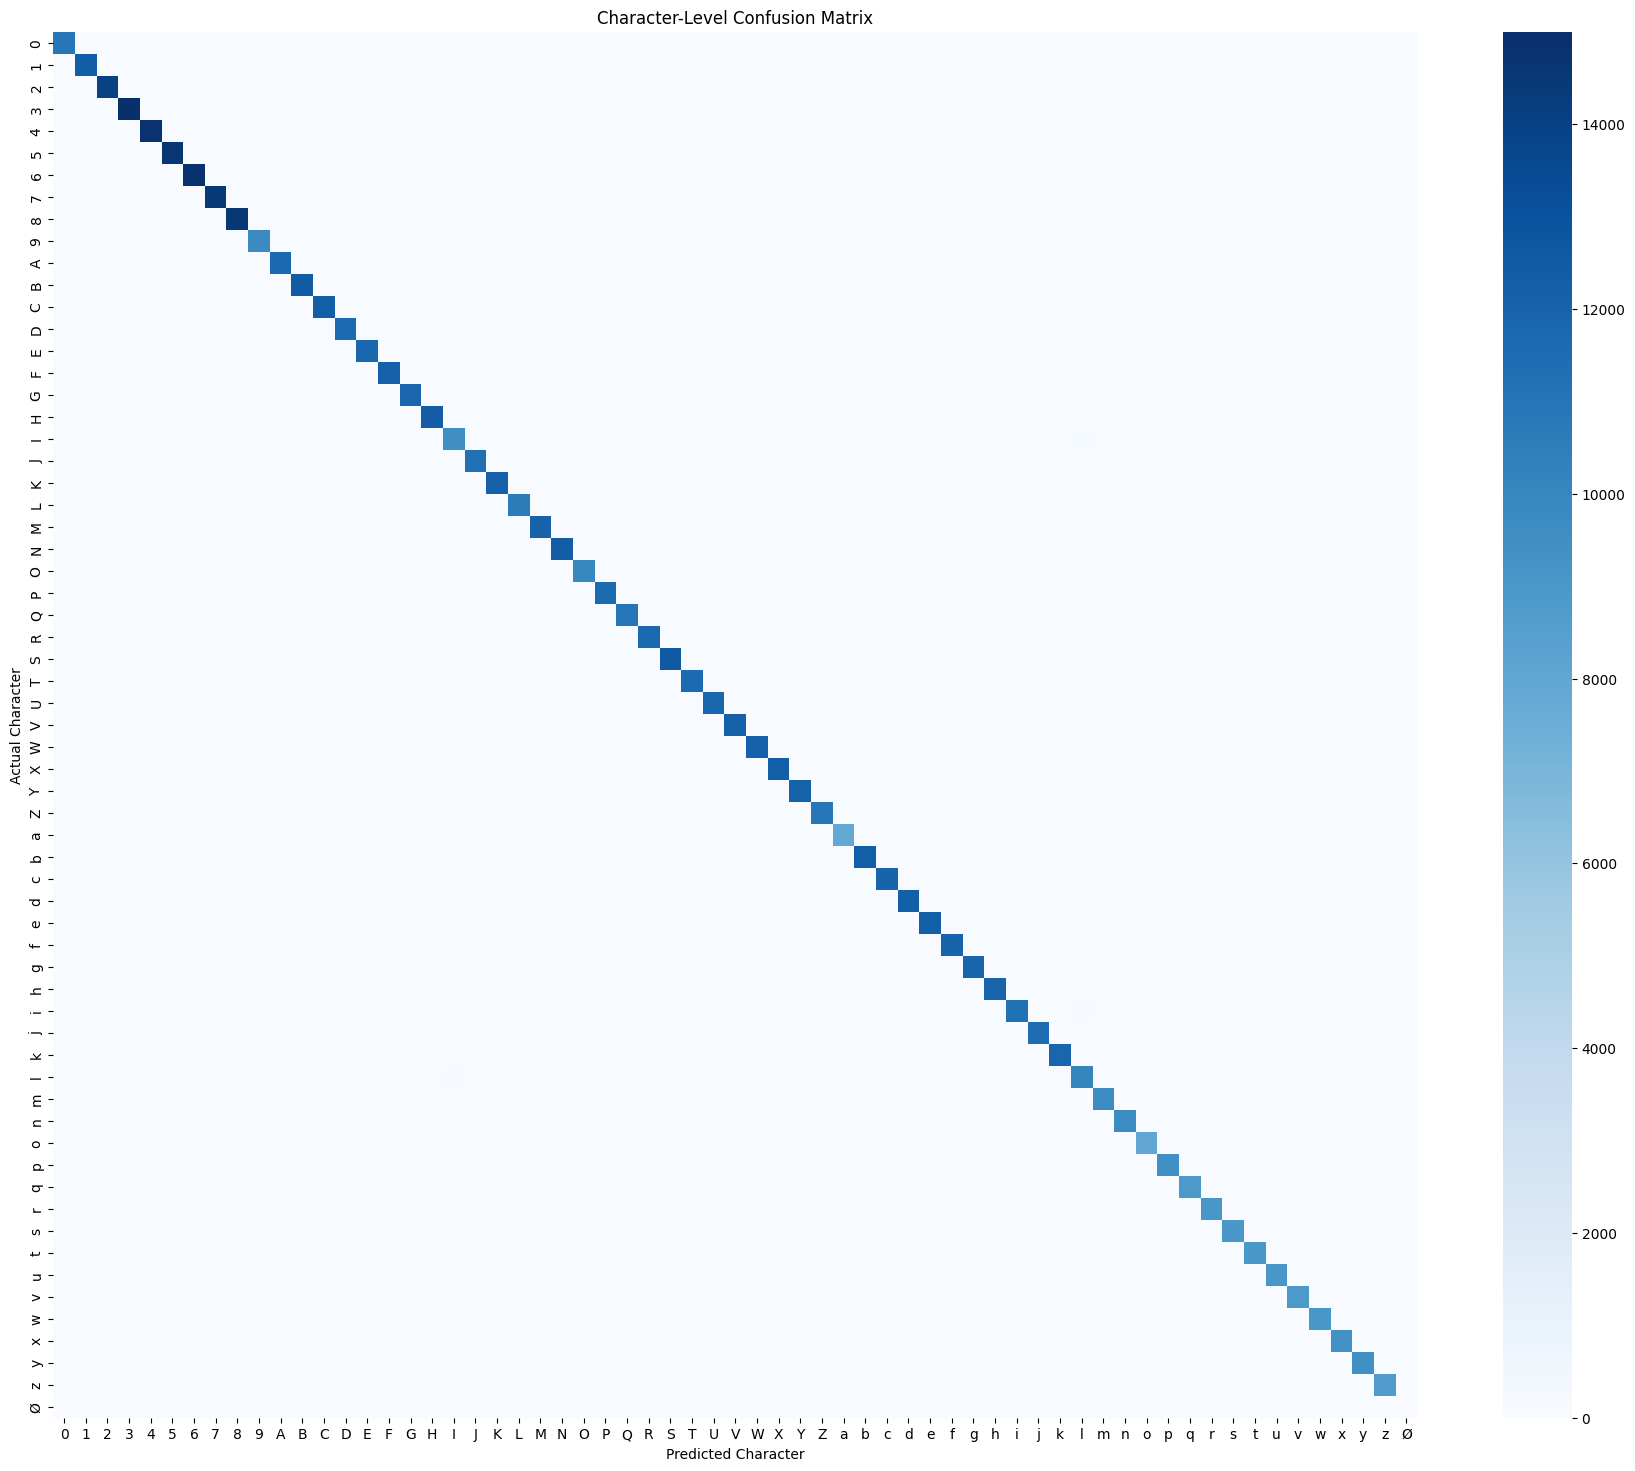

In [26]:
plot_char_confusion_matrix(df_test_results, hf_dataset)

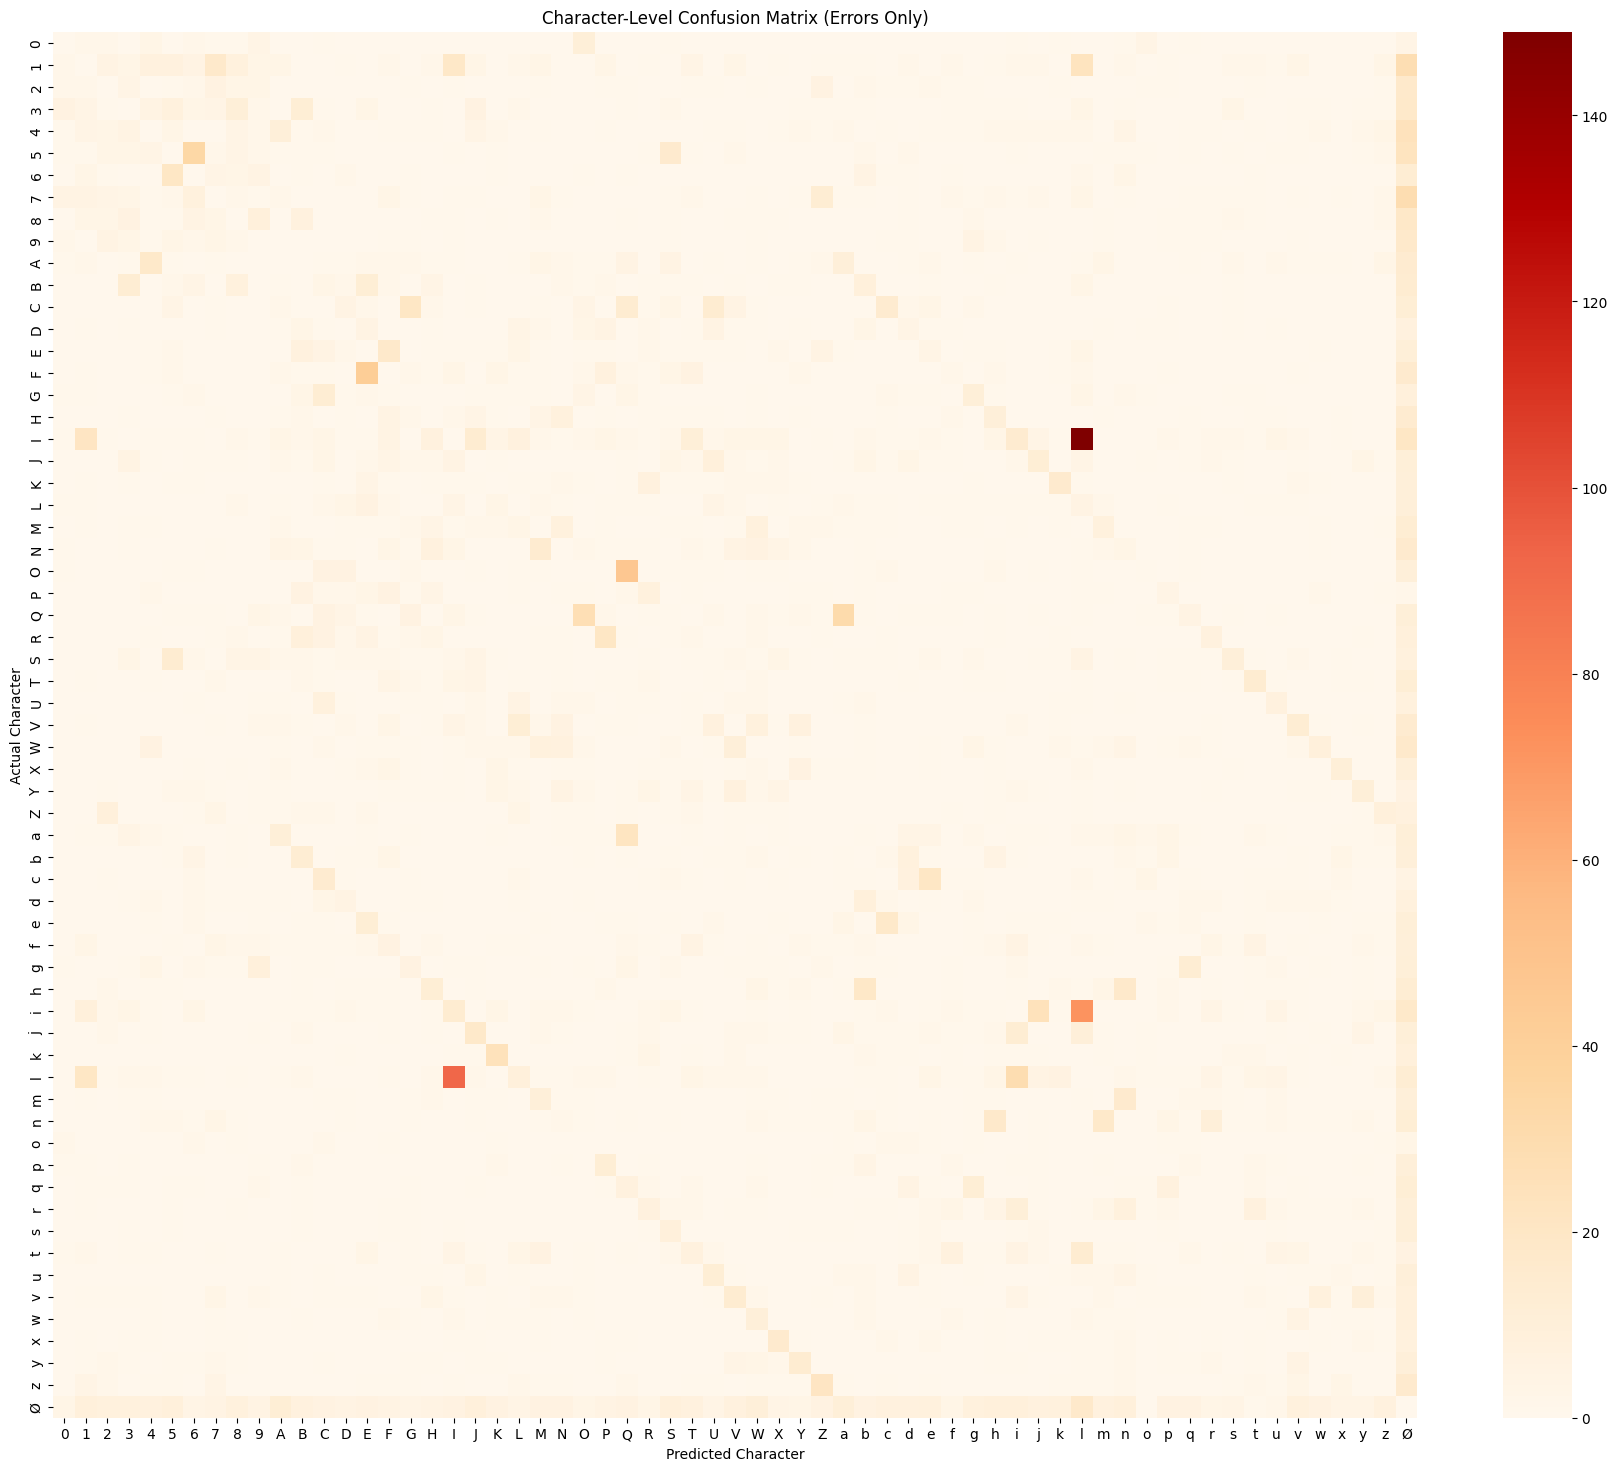

In [27]:
plot_char_confusion_matrix(df_test_results, hf_dataset, hide_diagonal=True)

# Visualize Random Predictions

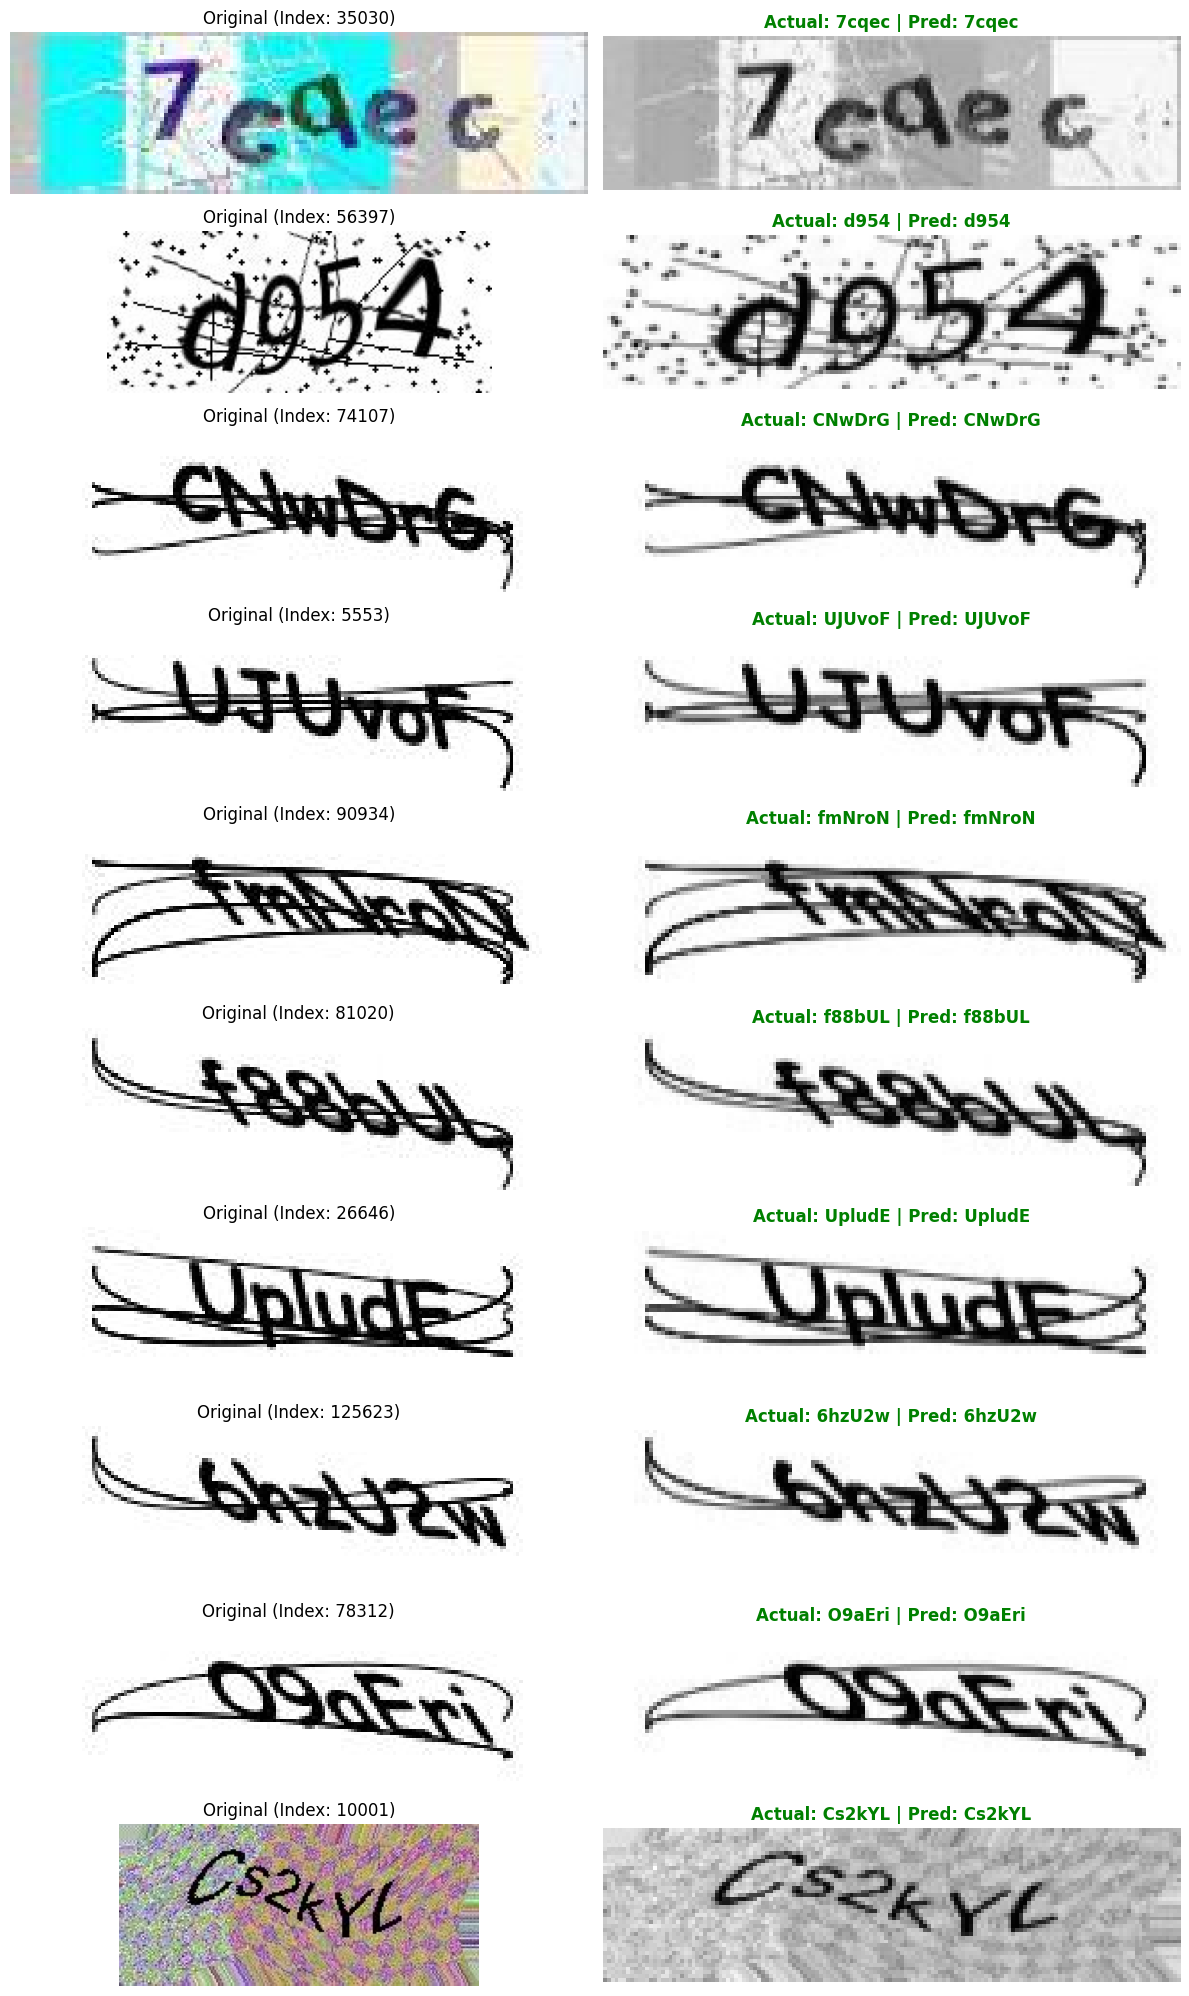

In [31]:
visualize_test_predictions(df_test_results, hf_dataset, 10)

# Visualize Random Wrong Predictions

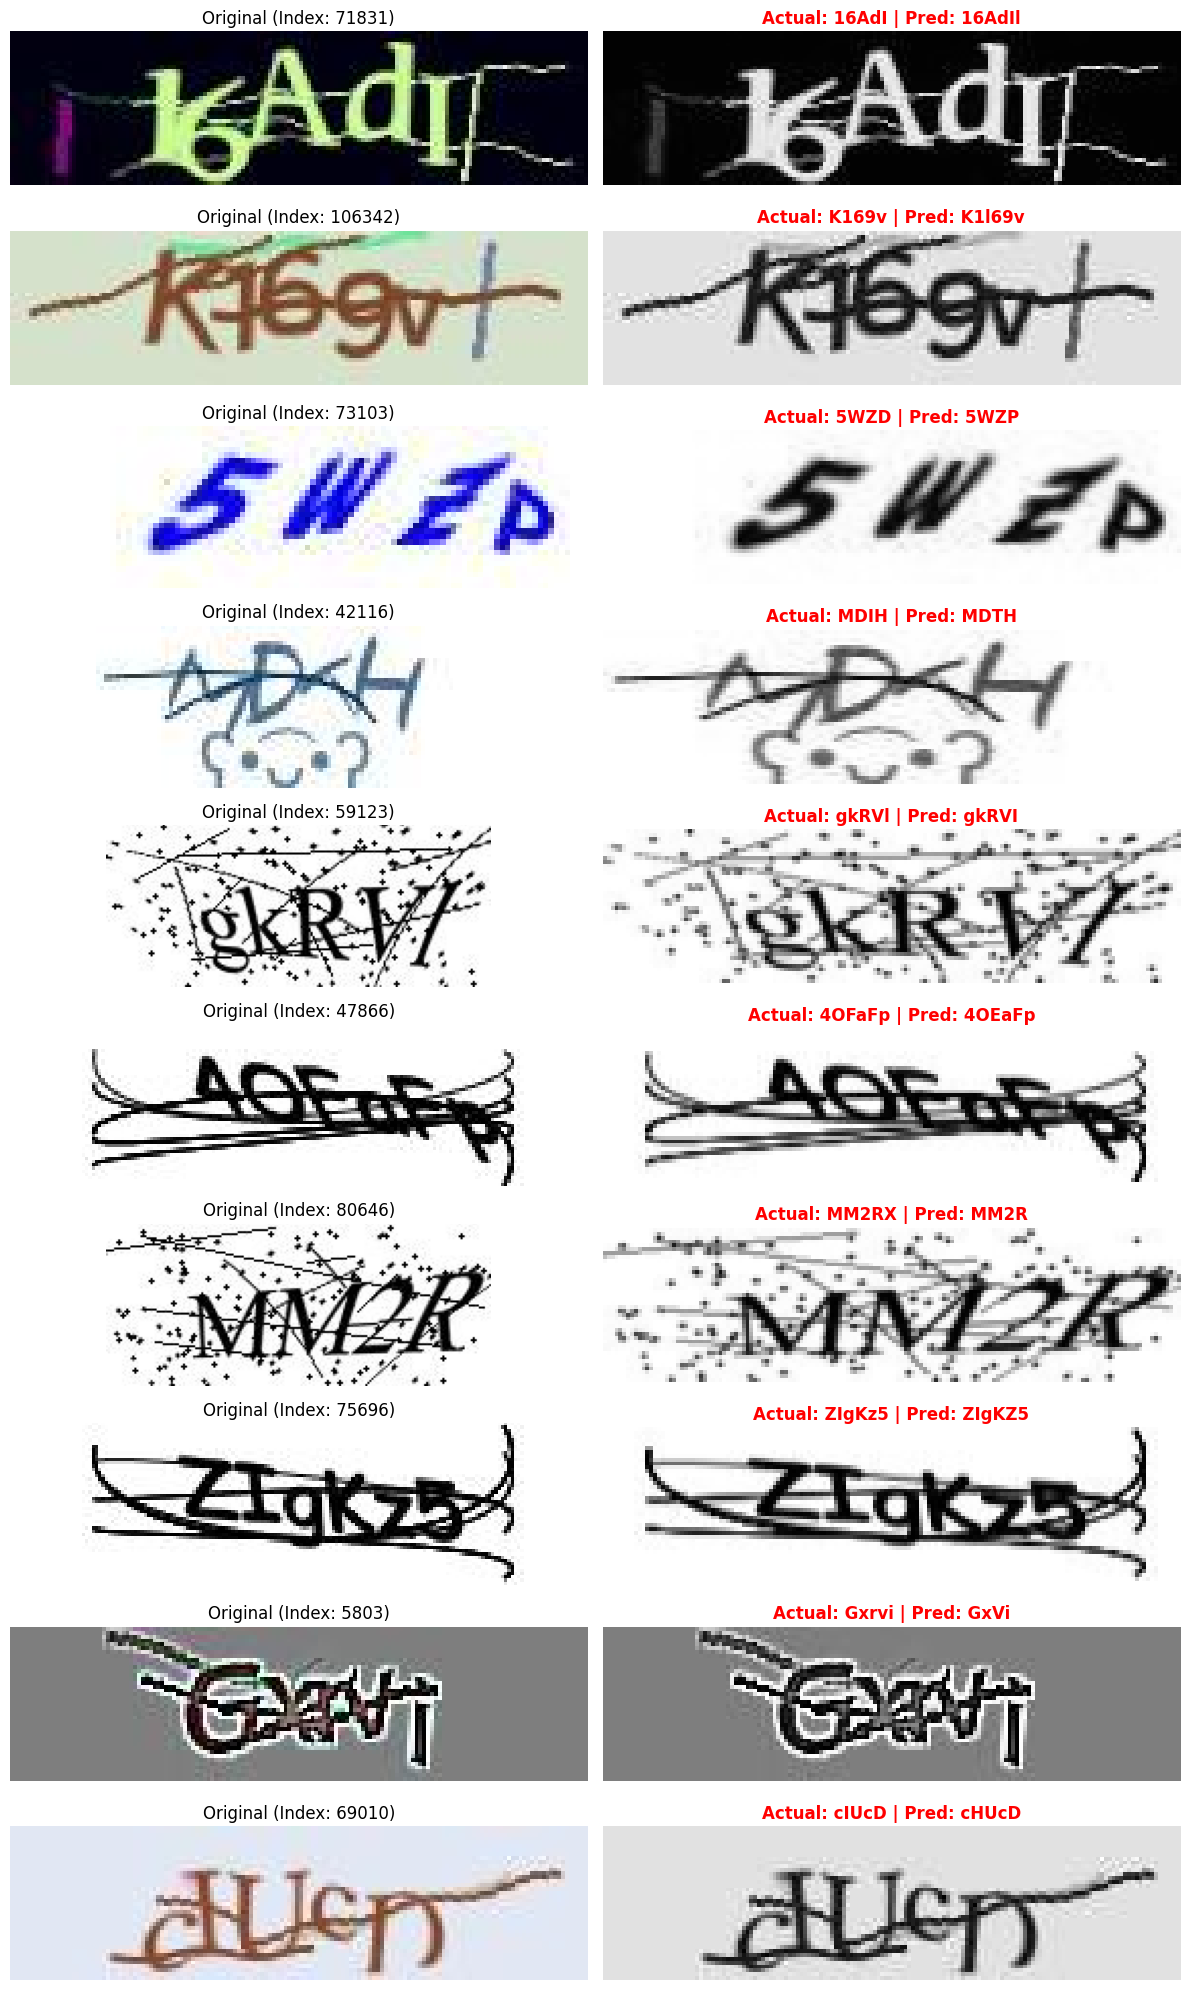

In [32]:
visualize_test_predictions(df_test_results[df_test_results["actual"] != df_test_results["prediction"]], hf_dataset, 10)

# Model Stats

In [33]:
model_stats = summary(model, input_size=(1, 1, 40, 150), verbose=0)
print(f"Total Parameters: {model_stats.total_params:,}")
print(f"Model Size (MB): {model_stats.total_param_bytes / 1e6:.2f} MB")

Total Parameters: 12,279,551
Model Size (MB): 22.88 MB


# Inference

In [22]:
def benchmark_inference(model, device, input_shape=(1, 1, 40, 150), num_iterations=1000):
    model.eval()
    dummy_input = torch.randn(*input_shape).to(device)
    
    # Warm-up (Standard for GPU benchmarking)
    for _ in range(10):
        _ = model(dummy_input)
    
    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_time = time.time()
    
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
            
    torch.cuda.synchronize() if device.type == 'cuda' else None
    end_time = time.time()
    
    total_time = end_time - start_time
    avg_latency = (total_time / num_iterations) * 1000 # in ms
    throughput = num_iterations / total_time # items per second
    
    print(f"Average Latency: {avg_latency:.2f} ms")
    print(f"Throughput: {throughput:.2f} images/sec")

benchmark_inference(model, device)

Average Latency: 1.38 ms
Throughput: 724.56 images/sec


### Hugging-Face Test-Data
Metric|Conv-Trans-V4|Conv-Trans-V5|Conv-Trans-V6    |
------|--|--|-----------|
Accuracy|97.38%|91.99%|95.36% |
Character-Error-Rate (CER)|0.57%|1.83%|1.03% |
Model Parameters|12,279,551|12,279,551|12,279,551 |
Model Size (MB)|22.88 MB|22.88 MB|22.88 MB |
Images/Second|724.56 (GPU)|768.22 (GPU)|768.22 (GPU) |

The currently best model existing is [anuashok/ocr-captcha-v3](https://huggingface.co/anuashok/ocr-captcha-v3)  with ~10k downloads per month on HuggingFace which states this Character Error Rate:

$CER_{ocr} = 0.01394585726004922$

Our CRNN model states a Character Error Rate of:

$CER_{ct} = 0.0057$

Since the dataset the [anuashok/ocr-captcha-v3](https://huggingface.co/anuashok/ocr-captcha-v3) got trained on is not provided I approximate the accuracy of this model by projecting onto the typical CAPTCHA CER to Accuracy relationship discovered our dataset, under the assumption that the characters are IID:

$$
\begin{split}
    Accuracy_{ct} = (1 - CER_{ct})^{\hat{l}} \\
    \hat{l} \cdot log(1 - CER_{ct}) = log(Accuracy_{ct}) \\
    \hat{l} = \frac{log(Accuracy_{ct})}{log(1 - CER_{ct})} \\
    \hat{l} = \underline{4.64}
\end{split}
$$

Now use CAPTCHA length estimate $\hat{l}$ to estimate Accuracy of [anuashok/ocr-captcha-v3](https://huggingface.co/anuashok/ocr-captcha-v3):

$$
\begin{split}
    \hat{Accuracy_{ocr}} = (1 - CER_{ocr})^{\hat{l}} \\
    \hat{Accuracy_{ocr}} = \underline{93.69\%}
\end{split}
$$


The Test-CER of the ConvTrans-V4 model is about $0.57\%$ better than the currently leading model on HuggingFace: https://huggingface.co/anuashok/ocr-captcha-v3 which is a fine-tuned version of https://huggingface.co/microsoft/trocr-base-printed

This difference seems to be small but it stacks up because this is a sequence problem. Therefore while my model has a $97.38\%$ Accuracy the finetuned Microsoft model is approximated to only have around $93.69\%$ Accuracy, which is a big $3.69\%$ difference for full sequence accuracy.